In [1]:
using JLD2
using Plots

In [14]:
data = jldopen("../25_12_05_output/collated_results.jld2")["results"];

In [ ]:
# summary:

# L = 8, 16, 24
# T = 10L
# p = 0.05, 0.1
# q = 0.0, 0.05, ..., 0.3
# peff = q + 2p(1-p)
# each point is 500 samples

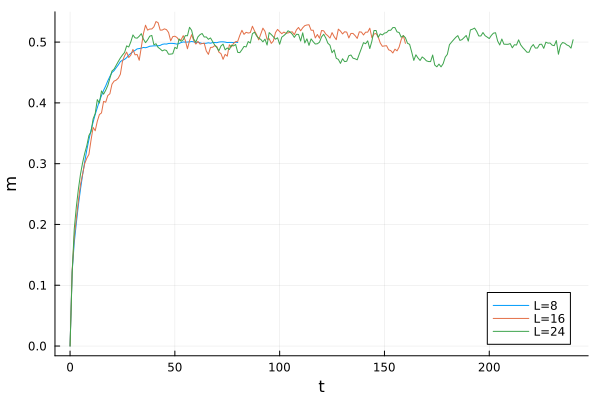

In [15]:
plt = plot()

p = 0.1
q = 0.15
peff = q+2*p*(1-p)

for L in 8:8:24
    xs = 0:10L
    ys = data[("adv_MWPM", L, 10L, p, q, peff)][1]
    plot!(plt, xs, ys, label="L=$L", xlabel="t", ylabel="m")
end

plt

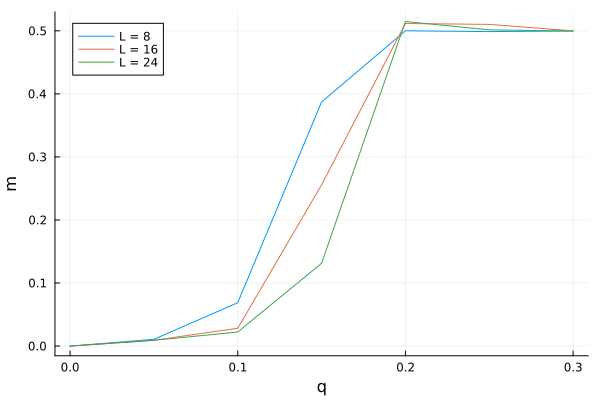

In [17]:
algo = "adv_MWPM"
p = 0.05
func(p,q) = q + 2p*(1-p)

plt = plot()
for L in 8:8:24
    qs = 0.0:0.05:0.3
    T = 10L
    ys = [data[(algo, L, 10L, p, q, func(p,q))][1][T] for q in qs]
    plot!(qs, ys, label="L = $L", xlabel="q", ylabel="m")
end

plt

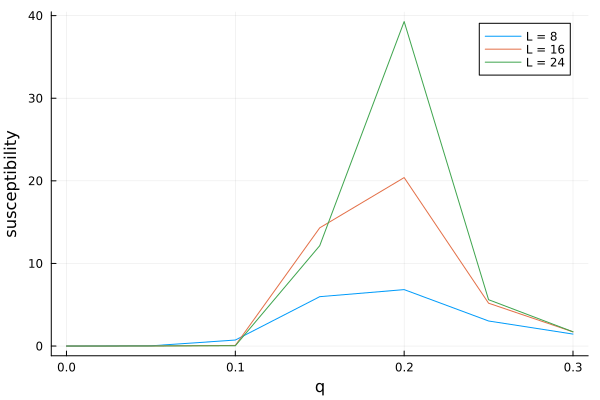

In [18]:
algo = "adv_MWPM"
p = 0.05
func(p,q) = q + 2p*(1-p)

plt = plot()
for L in 8:8:24
    qs = 0.0:0.05:0.3
    T = 3L
    ys = [data[(algo, L, 10L, p, q, func(p,q))][2][T] for q in qs] - [data[(algo, L, 10L, p, q, func(p,q))][1][T] for q in qs] .^ 2
    plot!(qs, L^2*ys, label="L = $L", xlabel="q", ylabel="susceptibility")
end

plt